# 🌸 인공지능(AI)을 활용한 데이터 분류 분석 체험
이번 시간에는 데이터베이스(`꽃데이터.db`)에 저장된 붓꽃의 특징(꽃잎, 꽃받침 데이터)을 AI에게 전달하여, AI가 스스로 데이터를 분석하고 꽃의 종류를 알아서 분류하는 과정을 체험합니다.

코딩을 하나도 몰라도 괜찮습니다! 우리가 데이터를 건네주면, 인공지능이 어떻게 스스로 규칙을 찾아내어 시각적으로 그림(트리)을 그려주는지 신기한 데이터 분석의 과정을 편안하게 경험해 보세요.

## 1단계: 분석 도구 준비하기
데이터베이스 접속과 시각화(그림 그리기)를 위해 필요한 기본 도구들을 불러옵니다.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
import koreanize_matplotlib

## 2단계: 데이터베이스(DB)에서 데이터 불러오기
우리의 목표는 데이터베이스에 저장된 표 형태의 데이터를 불러와 AI에게 전달하는 것입니다. 로컬 데이터베이스 파일(`꽃데이터.db`)에 접속하여 안에 들어있는 데이터를 읽어옵니다.

In [2]:
# DB 연결
conn = sqlite3.connect('꽃데이터.db')

# SQL 쿼리로 전체 데이터 로드
query = "SELECT * FROM 꽃데이터"
df = pd.read_sql(query, conn)

# 상위 5개 데이터 확인
df.head()

,꽃받침 길이 (cm),꽃받침 너비 (cm),꽃잎 길이 (cm),꽃잎 너비 (cm),꽃이름
0,5.1,3.5,1.4,0.2,세토사
1,4.9,3.0,1.4,0.2,세토사
2,4.7,3.2,1.3,0.2,세토사
3,4.6,3.1,1.5,0.2,세토사
4,5.0,3.6,1.4,0.2,세토사


## 3단계: AI에게 알려줄 '문제'와 '정답' 나누기
인공지능이 데이터의 패턴을 찾기 위해서는 문제(꽃의 특징)와 정답(꽃의 종류)을 구분해 주어야 합니다. 또한 AI를 공부시킬 데이터와 나중에 테스트해볼 데이터로 나눕니다.

In [3]:
# 특성(X)과 정답(y) 분리
X = df[['꽃받침 길이 (cm)', '꽃받침 너비 (cm)', '꽃잎 길이 (cm)', '꽃잎 너비 (cm)']]
y = df['꽃이름']

# 데이터를 학습용 80%, 테스트용 20% 비율로 분할 (Random State를 고정하여 결과 재현성 확보)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4단계: AI 공부시키기 및 실력 확인
AI에게 데이터를 주어 스스로 규칙을 찾도록 공부시킵니다. 공부가 끝나면, 처음 보는 새로운 꽃 데이터를 주었을 때 얼마나 똑똑하게 잘 분류해내는지 점수(%)로 AI의 실력을 확인해 봅니다.

In [4]:
# 1. 인공지능 모델 준비하기
ai_model = DecisionTreeClassifier(random_state=42)

# 2. 인공지능 공부시키기 (데이터 학습)
ai_model.fit(X_train, y_train)

# 3. AI 시험 보기 (정답 맞힌 비율 확인)
y_pred = ai_model.predict(X_test)
score = accuracy_score(y_test, y_pred) * 100

print(f"📊 AI의 데이터 분류 시험 점수: {score:.1f}점!")

📊 AI의 데이터 분류 시험 점수: 100.0점!


## 5단계: AI의 판단 기준 그림으로 보기 (트리 시각화)
학습을 마친 AI는 도대체 어떤 기준으로 꽃들을 분류했을까요?
AI가 방대한 데이터 속에서 스스로 만들어낸 판단 기준(마치 스무고개 같은 형태)을 그림으로 직접 확인해 봅시다!

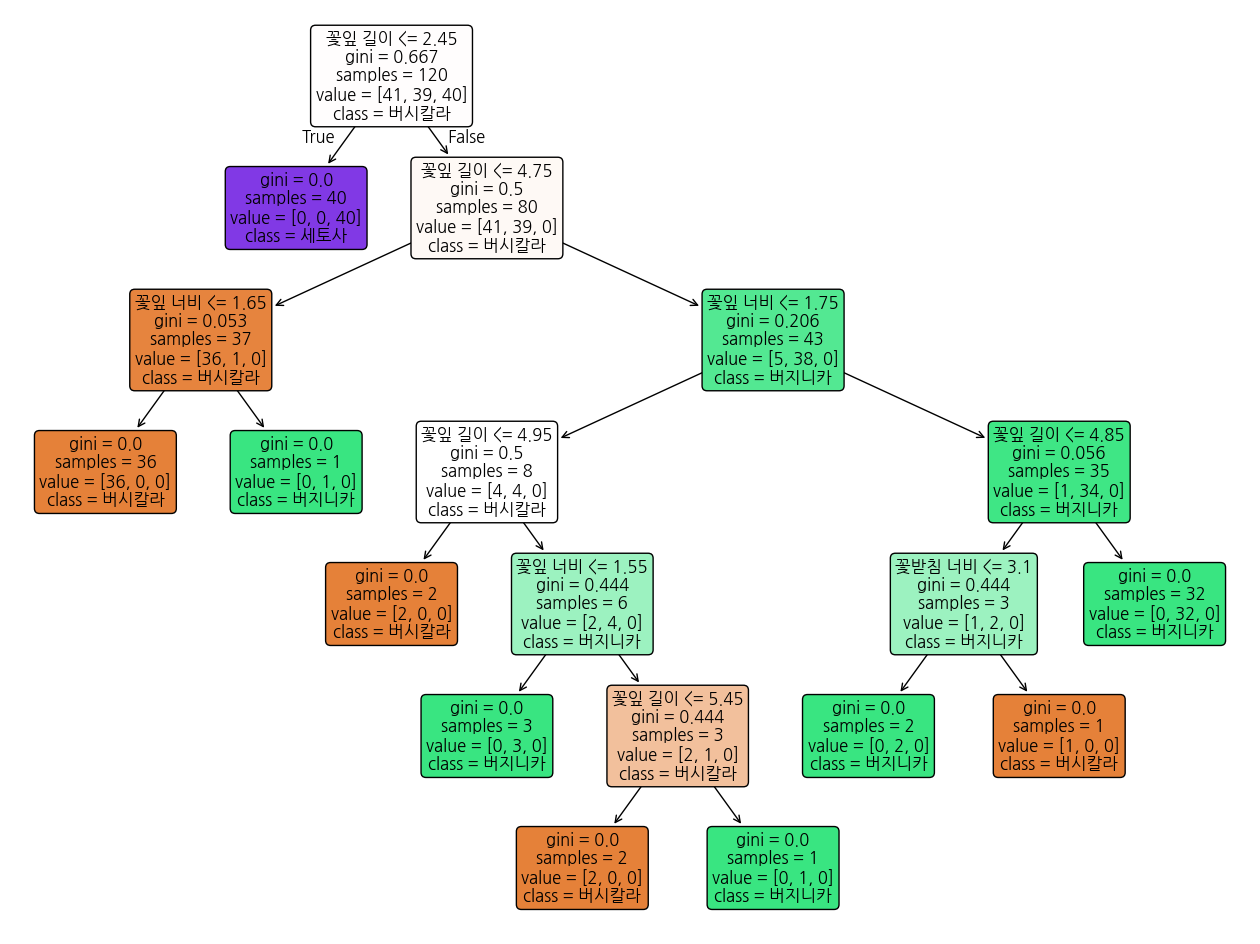

In [5]:
# 그림(시각화) 크기 설정
plt.figure(figsize=(16, 12))

# 학생들이 쉽게 이해할 수 있도록 안내 문구 추가
plt.title('AI의 판단 기준 (왼쪽 화살표 = True(예) / 오른쪽 화살표 = False(아니오))', fontsize=18, pad=20)

# AI가 생각한 기준을 트리 그림으로 나타내기
tree.plot_tree(ai_model, 
               feature_names=['꽃받침 길이', '꽃받침 너비', '꽃잎 길이', '꽃잎 너비'],  
               class_names=ai_model.classes_,
               filled=True,      # 박스에 색상 채우기
               fontsize=12,      # 글자 크기 키우기 (True/False가 잘 보이도록)
               rounded=True)     # 박스 모서리 둥글게

# 완성된 그림을 파일로 저장하기
plt.savefig('분석결과_트리.png', dpi=300, bbox_inches='tight')

# 그림 화면에 보여주기
plt.show()